# **Test for Areas Normalization**

In [19]:
import numpy as np
import pryngles as pr

%matplotlib inline
# from pyppluss.segment_models import LC_ring

## **System Parameters**

In [2]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 1.598212e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = 74.6*pr.DEG #Deg
roll = (90 - 56.9)*pr.DEG #Deg
fi, fe = 1, 6.452317 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

## **Building System**

In [3]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um, nspangles = 100,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = 0, i = (90 - inc)*pr.DEG,
                    radius = Rp/system.ul, nspangles = 100,
                    m = 0)

ring = system.add(kind = "Ring", parent = planet,
                  fi = fi, fe = fe, nspangles = 100,
                  i = i_ring, roll = roll - np.pi/2)

In [ ]:
system.initialize_simulation()
system.spangle_system()

## `normalize_areas()` **Method Validation**

In [5]:
cond_planet = (system.data.name == 'Planet')*(system.data.cos_obs >= 0)

expected_area = np.pi*planet.radius**2

facet_area = (system.data.asp_obs[cond_planet]*system.data.cos_obs[cond_planet]).sum()

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 1.3124542436524663e-08
Facet-Based Area: 1.3124542436524668e-08
Normalization Factor: 0.9999999999999997


In [6]:
cond_ring = (system.data.name == 'Ring')*(system.data.cos_obs >= 0)

expected_area = np.pi*(ring.re**2 - ring.ri**2)*system.data.cos_obs[cond_ring].iloc[0]

facet_area = (system.data.asp_obs[cond_ring]*system.data.cos_obs[cond_ring]).sum()

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 1.4161618806946275e-07
Facet-Based Area: 1.4161618806946248e-07
Normalization Factor: 1.0000000000000018


## `pypPlusS` **Areas Validation**

In [2]:
from pyppluss.segment_models import tot_hidden_area, planet_hidden_area
from pyppluss.base_functions import get_disk_planet_intersection, get_star_disk_intersection, get_star_planet_intersection, coord_swap

In [3]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 7.037276e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = 0*pr.DEG #Deg
roll = (90 - 0)*pr.DEG #Deg
fi, fe = 1, 1 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

In [4]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = e, i = (90 - inc)*pr.DEG,
                    radius = Rp/system.ul,
                    m = 0)

In [5]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

In [11]:
cond_planet = (system.data.name == 'Planet')*(system.data.cos_obs >= 0)

expected_area = np.pi*(planet.radius/star.radius)**2

facet_area = (system.data.asp_obs[cond_planet]*system.data.cos_obs[cond_planet]).sum()/star.radius**2

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 0.015558188937801788
Facet-Based Area: 0.015558188937801785
Normalization Factor: 1.0000000000000002


In [9]:
rhos_system = system.data.center_obs.iloc[-1][:2]/star.radius

x_star, y_star = coord_swap([rhos_system[0]],[rhos_system[1]], roll)

pyp_planet_area = planet_hidden_area(radius_planet = np.array([Rp/Rs]), x_star = x_star, y_star = y_star, tol=1e-10,
                                     star_planet_intersections = get_star_planet_intersection(x_star, y_star, np.array([Rp/Rs]), 1e-10))

print(f'pypPlusS Planet Hidden Area: {pyp_planet_area}')

pypPlusS Planet Hidden Area: [0.01555819]


## **Ring Hidden Area Validation**

In [15]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 1.598212e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = np.pi/2 #74.6*pr.DEG #Deg
roll = 0*(90 - 56.9)*pr.DEG #Deg
fi, fe = 1, 6.452317 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

In [21]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = 0, i = (90 - inc)*pr.DEG,
                    radius = Rp/system.ul,
                    m = 0)

ring = system.add(kind = "Ring", parent = planet,
                  fi = fi, fe = fe,
                  i = i_ring, roll = roll)

In [22]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

(0, 0)

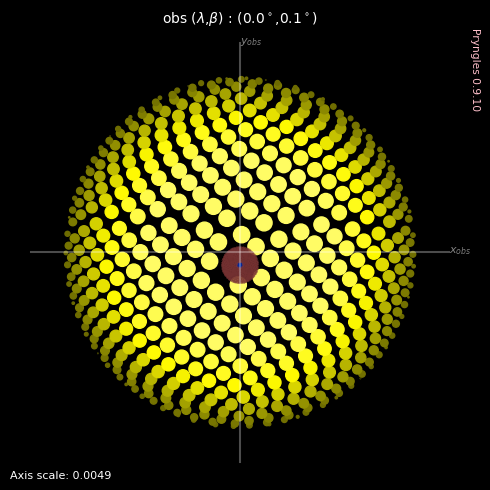

In [23]:
system.sg.plot2d()

In [24]:
cond_planet = (system.data.name == 'Planet')*(system.data.cos_obs >= 0)

expected_area = np.pi*(planet.radius/star.radius)**2

facet_area = (system.data.asp_obs[cond_planet]*system.data.cos_obs[cond_planet]).sum()/star.radius**2

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 0.0008024512300158876
Facet-Based Area: 0.0008024512300158868
Normalization Factor: 1.0000000000000009


In [31]:
cond_ring = (system.data.name == 'Ring')*(~system.data.hidden)

expected_area = np.pi*(ring.re**2 - ring.ri**2)/star.radius**2

facet_area = (system.data.asp_obs[cond_ring]).sum()/star.radius**2

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 0.03260551508021998
Facet-Based Area: 0.032605515080219825
Normalization Factor: 1.0000000000000047


In [30]:
R_planet = np.array([Rp/Rs])

rhos_system = system.data.center_obs.iloc[-1][:2]/star.radius

x_star, y_star = coord_swap([rhos_system[0]],[rhos_system[1]], roll)

pyp_planet_area = planet_hidden_area(radius_planet = np.array([Rp/Rs]), x_star = x_star, y_star = y_star, tol=1e-10,
                                     star_planet_intersections = get_star_planet_intersection(x_star, y_star, np.array([Rp/Rs]), 1e-10))

total_area = tot_hidden_area(radius_planet = R_planet, radius_in = fi*R_planet, radius_out = fe*R_planet,
                            x_star = x_star, y_star = y_star, ring_inclination = np.pi/2 - i_ring, opacity = 1, tol=1e-10,
                            star_planet_intersections = get_star_planet_intersection(x_star, y_star, R_planet, 1e-10),
                            star_disk_intersections_in = get_star_disk_intersection(x_star, y_star, fi*R_planet, np.pi/2 - i_ring, 1e-10),
                            star_disk_intersections_out = get_star_disk_intersection(x_star, y_star, fe*R_planet, np.pi/2 - i_ring, 1e-10),
                            disk_planet_intersections_in = get_disk_planet_intersection(R_planet, fi*R_planet, np.pi/2 - i_ring, 1e-10),
                            disk_planet_intersections_out = get_disk_planet_intersection(R_planet, fe*R_planet, np.pi/2 - i_ring, 1e-10))

print(f'pypPlusS Planet Hidden Area: {pyp_planet_area}\npypPlusS Ring Hidden Area: {total_area - pyp_planet_area}')

pypPlusS Planet Hidden Area: [0.00080245]
pypPlusS Ring Hidden Area: [0.03260552]
